# Unit 0, Notebook 2: Limits, Precision, and Infinity

In the last notebook, we learned how to translate mathematical functions into Python. Now, we are going to touch on the foundational concept of all calculus: **the limit**.

A limit is simply asking: *"As our x-value gets really, really close to a specific number, what does our y-value get close to?"* However, because we are using code to do our math, we are going to run into the physical limitations of computers. Let's import our tools and dive in.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # We will use pandas just to make pretty tables!

## 1. The Intuitive Limit

Let's look at a classic calculus function:


$$f(x) = \frac{\sin(x)}{x}$$

What happens when $x

In [2]:
f = lambda x: np.sin(x) / x

# Create an array of x-values getting closer and closer to 0
x_approaching_zero = np.array([1.0, 0.1, 0.01, 0.001, 0.0001, 0.00001])

# Evaluate the function
y_values = f(x_approaching_zero)

# Put it in a table for easy reading
limit_table = pd.DataFrame({
    'x-value': x_approaching_zero,
    'f(x) output': y_values
})

print(limit_table)

   x-value  f(x) output
0  1.00000     0.841471
1  0.10000     0.998334
2  0.01000     0.999983
3  0.00100     1.000000
4  0.00010     1.000000
5  0.00001     1.000000


As $x$ gets smaller and smaller, the output clearly converges to **1.0**. We have just numerically evaluated a limit!

## 2. The Floating-Point Reality Check

If calculus is all about making things infinitely small, we need to address a dark secret of computer science. Run the code cell below.


In [3]:
print("0.1 + 0.2 =", 0.1 + 0.2)


0.1 + 0.2 = 0.30000000000000004


Wait, why did Python output **0.30000000000000004**?

Computers think in binary (1s and 0s). Just like how the fraction $1/3$ cannot be written perfectly in our base-10 decimal system (it's $0.33333...$), fractions like $1/10$ (0.1) cannot be written perfectly in binary. The computer has to round it off at a microscopic level.

This rounding error is called **floating-point inaccuracy**. For everyday coding, it doesn't matter. For calculus, where we deal with the infinitely small, it is a massive deal.

## 3. The Danger of "Too Small"

Let's return to our limit function:


$$f(x) = \frac{\sin(x)}{x}$$

We know the limit approaches 1 as $x$ approaches 0. What if we try to be hyper-accurate and give the computer incredibly tiny numbers, like $10^{-16}$ or $10^{-17}$?


In [4]:
# Create an array of ultra-tiny x-values
tiny_x = np.array([1e-15, 1e-16, 1e-17, 1e-18])

# Evaluate the function again
tiny_y = f(tiny_x)

tiny_table = pd.DataFrame({
    'ultra-tiny x': tiny_x,
    'f(x) output': tiny_y
})

print(tiny_table)

   ultra-tiny x  f(x) output
0  1.000000e-15          1.0
1  1.000000e-16          1.0
2  1.000000e-17          1.0
3  1.000000e-18          1.0


The math completely broke! Instead of 1.0, the computer suddenly output 0.0.

Because of the floating-point limits we just learned about, the computer simply lacks the memory to distinguish $10^{-18}$ from actual zero. When evaluating numerical limits and derivatives, **step sizes that are too small will destroy your results.** We have to find a "Goldilocks zone" for our code.

## 4. Asymptotes and Infinity

What happens when a limit actually approaches infinity? Let's look at:


$$g(x) = \frac{1}{x}$$

If you divide by zero in standard Python, it crashes your program.


In [5]:
# Uncommenting the line below will cause a ZeroDivisionError!
# print(1 / 0)


However, `numpy` is built for higher math. If we force `numpy` to divide by zero, it doesn't crash. It issues a polite warning and returns `inf` (infinity).


In [6]:
# Using a numpy array to hold the number 0
zero_array = np.array([0.0])

# Numpy handles the division
infinity_result = 1 / zero_array

print("1 / 0 in numpy is:", infinity_result)


1 / 0 in numpy is: [inf]


/tmp/ipykernel_12428/2784208351.py:5: RuntimeWarning: divide by zero encountered in divide
  infinity_result = 1 / zero_array


Let's visualize this asymptote. We need to be careful when graphing functions that shoot off to infinity, or our graph will look like a mess. We will use `plt.ylim()` to restrict our vertical view.


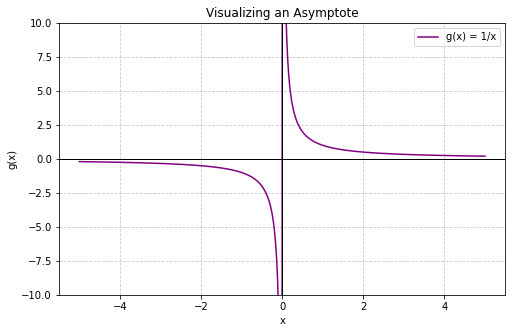

In [7]:
# Create x values from -5 to 5
x_vals = np.linspace(-5, 5, 400)

g = lambda x: 1 / x

# Evaluate the function (numpy will warn us about the 0, but will still work)
y_vals = g(x_vals)

plt.figure(figsize=(8, 5))

# Plot the graph
plt.plot(x_vals, y_vals, color='purple', label="g(x) = 1/x")

# Set the y-limits so the graph doesn't stretch to infinity
plt.ylim(-10, 10)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Visualizing an Asymptote")
plt.xlabel("x")
plt.ylabel("g(x)")
plt.legend()

plt.show()
